# Phase 2 — Data & Prediction Divergence

Companion to `phase2_model_development.ipynb`. While that notebook asks *did model quality improve?*, this notebook asks *did the underlying data change?*

Everything here reads pre-computed artifacts from `make repro`:

- `reports/divergence/phase2_divergence_report.json`
- `reports/divergence/phase2_divergence_summary.md`
- `data/interim/source_manifest.csv` (row → source mapping)
- `data/interim/phishing_email_phase1_reference.csv`, `phishing_email_phase2_increment.csv`

The divergence math itself lives in `src/mlops_crew/monitoring/divergence.py` and uses Jensen-Shannon distance for categorical distributions plus a Kolmogorov-Smirnov test for text-length distributions, with the same TF-IDF token pattern as training so the vocabulary view is consistent with what the model actually sees.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from mlops_crew.config import CONFIG_PATH, load_project_config, resolve_project_path
from mlops_crew.data import LABEL_COLUMN, RAW_INDEX_COLUMN, TEXT_COLUMN

config = load_project_config(CONFIG_PATH)
interim_dir = resolve_project_path(config["data"]["interim_dir"])
divergence_dir = resolve_project_path(config["reports"]["divergence_dir"])
models_dir = resolve_project_path(config["modeling"]["output_dir"])

report = json.loads((divergence_dir / "phase2_divergence_report.json").read_text())
print("Top-level divergence keys:", list(report.keys()))

Top-level divergence keys: ['label_distribution', 'phase1_reference_rows', 'phase2_increment_rows', 'prediction_distribution', 'source_distribution', 'text_length', 'vocabulary']


## 1. Label-distribution drift

Stratified sampling should keep the phishing / legit ratio close to identical between Phase 1 and the Phase 2 increment. Jensen-Shannon distance close to zero means the two distributions are nearly indistinguishable.

In [2]:
label = report["label_distribution"]
label_df = pd.DataFrame(
    {
        "phase1_reference": label["phase1_reference"],
        "phase2_increment": label["phase2_increment"],
    }
)
label_df["phase1_pct"] = (label_df["phase1_reference"] / label_df["phase1_reference"].sum()).round(
    4
)
label_df["phase2_pct"] = (label_df["phase2_increment"] / label_df["phase2_increment"].sum()).round(
    4
)
print(f"Label Jensen-Shannon distance: {label['jensen_shannon_distance']:.6f}")
label_df

Label Jensen-Shannon distance: 0.000007


,phase1_reference,phase2_increment,phase1_pct,phase2_pct
0,23757,7919,0.48,0.48
1,25735,8578,0.52,0.52


## 2. Source-distribution drift

Joined on the source manifest. If the source mix changed (say, one source CSV stopped being delivered), source JS distance would jump.

In [3]:
source = report["source_distribution"]
source_df = (
    pd.DataFrame(
        {
            "phase1_reference": source["phase1_reference"],
            "phase2_increment": source["phase2_increment"],
        }
    )
    .fillna(0)
    .astype(int)
)
source_df["phase1_pct"] = (
    source_df["phase1_reference"] / source_df["phase1_reference"].sum()
).round(4)
source_df["phase2_pct"] = (
    source_df["phase2_increment"] / source_df["phase2_increment"].sum()
).round(4)
print(f"Source JS distance: {source['jensen_shannon_distance']}")
source_df.sort_values("phase1_reference", ascending=False)

Source JS distance: 0.014327239040413681


,phase1_reference,phase2_increment,phase1_pct,phase2_pct
ceas_08,23344,8004,0.4717,0.4852
enron,17989,5777,0.3635,0.3502
spamassassin,3501,1157,0.0707,0.0701
nigerian_fraud,2050,627,0.0414,0.0380
ling,1662,621,0.0336,0.0376
nazario,946,311,0.0191,0.0189


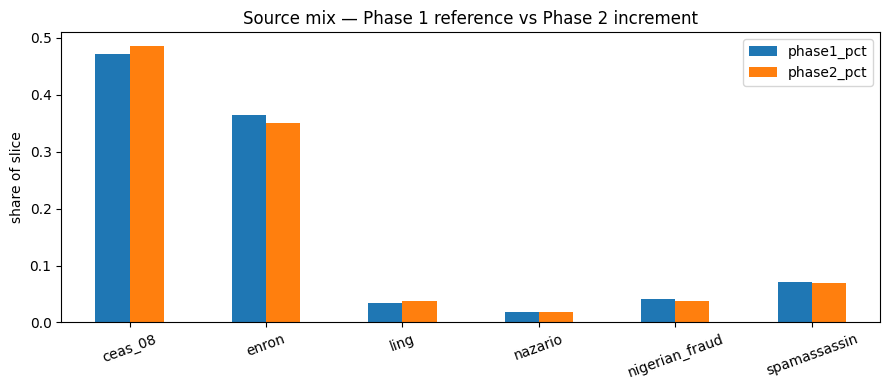

In [4]:
ax = source_df[["phase1_pct", "phase2_pct"]].plot.bar(figsize=(9, 4))
ax.set_ylabel("share of slice")
ax.set_title("Source mix — Phase 1 reference vs Phase 2 increment")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 3. Text-length drift

Kolmogorov-Smirnov on character lengths. A very small KS statistic + p-value near 1 means the two slices look identical in length distribution.

In [5]:
tl = report["text_length"]
pd.DataFrame(
    {
        "phase1_reference": tl["phase1_reference"],
        "phase2_increment": tl["phase2_increment"],
    }
).assign(ks_statistic=tl["ks_statistic"], ks_pvalue=tl["ks_pvalue"])

,phase1_reference,phase2_increment,ks_statistic,ks_pvalue
max,4.279526e+06,160318.000000,0.005134,0.898349
mean,1.322381e+03,1236.253561,0.005134,0.898349
median,5.600000e+02,560.000000,0.005134,0.898349
p90,2.762000e+03,2768.000000,0.005134,0.898349


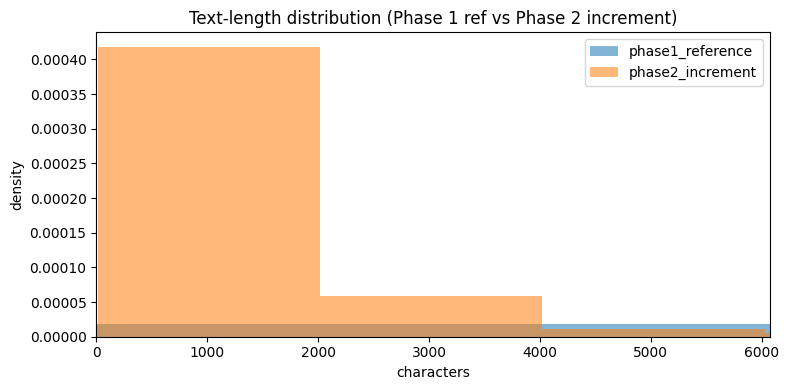

In [6]:
phase1_ref = pd.read_csv(interim_dir / config["data"]["phase1_reference_file"])
phase2_inc = pd.read_csv(interim_dir / config["data"]["phase2_increment_file"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    phase1_ref[TEXT_COLUMN].astype(str).str.len(),
    bins=80,
    alpha=0.55,
    label="phase1_reference",
    density=True,
)
ax.hist(
    phase2_inc[TEXT_COLUMN].astype(str).str.len(),
    bins=80,
    alpha=0.55,
    label="phase2_increment",
    density=True,
)
ax.set_xlim(0, phase1_ref[TEXT_COLUMN].astype(str).str.len().quantile(0.98))
ax.set_xlabel("characters")
ax.set_ylabel("density")
ax.set_title("Text-length distribution (Phase 1 ref vs Phase 2 increment)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Vocabulary drift

How much of the Phase 2 vocabulary is genuinely new compared with Phase 1? Low `new_token_rate` means the model's existing TF-IDF vocabulary still covers the new traffic.

In [7]:
vocab = report["vocabulary"]
print({k: v for k, v in vocab.items() if k != "top_new_tokens"})
pd.DataFrame(vocab["top_new_tokens"]).head(20)

{'current_vocab_size': 195796, 'new_token_count': 81540, 'new_token_rate': 0.03985534349981813, 'reference_vocab_size': 474481}


,count,token
0,58,031708
1,54,rolete
2,50,082229
3,43,2542235
4,41,2553695
5,41,megola
6,39,031808
7,37,postfixqmgr
8,34,httpairsaharaindiatimescom
9,34,httpwwwbestsellersindiatimescom


## 5. Prediction drift

Run the Phase 2 best model on both slices and compare the predicted-label distributions. Same JS-distance interpretation as the label distributions above.

In [8]:
pred = report["prediction_distribution"]
pred_df = (
    pd.DataFrame(
        {
            "phase1_reference": pred["phase1_reference"],
            "phase2_increment": pred["phase2_increment"],
        }
    )
    .fillna(0)
    .astype(int)
)
pred_df["phase1_pct"] = (pred_df["phase1_reference"] / pred_df["phase1_reference"].sum()).round(4)
pred_df["phase2_pct"] = (pred_df["phase2_increment"] / pred_df["phase2_increment"].sum()).round(4)
print(f"Prediction JS distance: {pred['jensen_shannon_distance']:.6f}")
pred_df

Prediction JS distance: 0.000207


,phase1_reference,phase2_increment,phase1_pct,phase2_pct
0,23713,7909,0.4791,0.4794
1,25779,8588,0.5209,0.5206


## 6. False negatives by source (recall is what we care about)

Cross the Phase 2 increment with the source manifest, score it with the saved best model, and see which source contributes the most false negatives.

In [9]:
manifest = pd.read_csv(interim_dir / config["data"]["source_manifest_file"])
best_model = joblib.load(models_dir / "best_model.joblib")

scored = phase2_inc.merge(manifest[[RAW_INDEX_COLUMN, "source"]], on=RAW_INDEX_COLUMN, how="left")
scored["prediction"] = best_model.predict(scored[TEXT_COLUMN].astype(str))


def slice_stats(group: pd.DataFrame) -> pd.Series:
    pos = group[group[LABEL_COLUMN] == 1]
    neg = group[group[LABEL_COLUMN] == 0]
    fn = (pos["prediction"] == 0).sum()
    fp = (neg["prediction"] == 1).sum()
    return pd.Series(
        {
            "rows": int(len(group)),
            "positives": int(len(pos)),
            "negatives": int(len(neg)),
            "false_negatives": int(fn),
            "false_positives": int(fp),
            "recall": float(1 - fn / len(pos)) if len(pos) else float("nan"),
            "false_negative_rate": float(fn / len(pos)) if len(pos) else float("nan"),
        }
    )


scored.groupby("source", dropna=False).apply(slice_stats).round(4).sort_values(
    "false_negatives", ascending=False
)

/var/folders/pc/1fr1sz8j27l45vcjzqzbd_cm0000gn/T/ipykernel_71893/2091130599.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scored.groupby("source", dropna=False).apply(slice_stats).round(4).sort_values(


,rows,positives,negatives,false_negatives,false_positives,recall,false_negative_rate
source,,,,,,,
enron,5777.0,2699.0,3078.0,15.0,17.0,0.9944,0.0056
ling,621.0,80.0,541.0,2.0,1.0,0.9750,0.0250
ceas_08,8004.0,4498.0,3506.0,1.0,9.0,0.9998,0.0002
nazario,311.0,311.0,0.0,1.0,0.0,0.9968,0.0032
spamassassin,1157.0,363.0,794.0,1.0,3.0,0.9972,0.0028
nigerian_fraud,627.0,627.0,0.0,0.0,0.0,1.0000,0.0000


## 7. Auto-generated divergence summary (committed)

In [10]:
print((divergence_dir / "phase2_divergence_summary.md").read_text())

# Phase 2 Divergence Summary

- Phase 1 reference rows: 49492
- Phase 2 increment rows: 16497
- Label distribution Phase 1: 0: 23757, 1: 25735
- Label distribution Phase 2 increment: 0: 7919, 1: 8578
- Label JS distance: 0.000007
- Source distribution Phase 1: ceas_08: 23344, enron: 17989, ling: 1662, nazario: 946, nigerian_fraud: 2050, spamassassin: 3501
- Source distribution Phase 2 increment: ceas_08: 8004, enron: 5777, ling: 621, nazario: 311, nigerian_fraud: 627, spamassassin: 1157
- Text length KS statistic: 0.005134
- New-token rate in Phase 2 increment: 0.039855
- Prediction distribution Phase 1: 0: 23713, 1: 25779
- Prediction distribution Phase 2 increment: 0: 7909, 1: 8588
- Prediction JS distance: 0.000207



## 8. Reading the divergence numbers

- **Label JS ≈ 0** → stratified sampling worked; phishing / legit ratio is intact in the Phase 2 increment.
- **Source JS small** → no source disappeared or surged. The new 20 % is a representative slice of the same six sources, not a new one.
- **KS p-value high** → text-length distribution unchanged.
- **New-token rate small** → the TF-IDF vocabulary trained on Phase 1 still covers most of the new traffic; we are not seeing a totally new dialect.
- **Prediction JS ≈ 0** → the saved model produces virtually the same prediction balance on both slices.

Net interpretation: the new 20 % does **not** look out-of-distribution. Any quality improvement from Phase 2 (see the model-development notebook) is attributable to *more data + new model families*, not to a different data regime.

If a future increment shifts any of these metrics (especially the source mix or the new-token rate), the divergence stage will surface it in the next `dvc repro`.